# Cow identity prediction: 70% TRAIN / 10% VALIDATION / 20% TEST

| Partition | Chronological position within each cow | Target share |
|---|---|---:|
| Training | Earliest observations | 70% |
| Validation | Next observations | 10% |
| Test | Most recent observations | 20% |

**Sole goal:** predict `animal_number` for an unidentified record using previous labeled cow records. No missing-measurement prediction model is included. The code, report, and plot use the same split configuration below.
This notebook uses **`filtered_by_z` from `project_1_notebook.ipynb`**, then creates `train_df`, `validation_df`, and `test_df`. The actual columns are `animal_number` and `event_date`. The cleaned source is copied and never overwritten.

Run all cells in order in this notebook. An isolated namespace rebuilds the cleaned dataframe by executing only the source notebook's loading, duplicate removal, and final z-score filtering cells. It does not execute package installations, HTML reports, or Git operations. This preserves the source cleaning lineage: `data -> clean_data -> filtered_by_z`. The separate `filtered_data` missing/zero-value filter is NOT an input to `filtered_by_z` in the source notebook and is therefore not added here.

The duplicate-removal cell contains four stale column names. The loader explicitly maps them to the actual renamed columns in memory and prints that repair; the original notebook remains unchanged. The CSV is read only as part of rebuilding the source notebook's cleaned dataframe, not used directly as the split input.

**Inherited limitations:** the source cleaning calculates z-score means and standard deviations across all `clean_data`, then removes rows with any absolute z-score above 2. This uses future data and can bias evaluation; splitting afterward cannot undo it. The source loader also reads large cow IDs as floats, potentially losing precision. This notebook preserves that existing representation rather than claiming to recover original exact IDs. New preprocessing is training-only and historical features use earlier training observations only. For a fully leakage-free evaluation, the source cleaning itself must be redesigned to fit thresholds after splitting.

Dependencies: pandas, numpy, matplotlib, scikit-learn, IPython.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SOURCE_NOTEBOOK = Path('project_1_notebook.ipynb')
source_notebook = json.loads(SOURCE_NOTEBOOK.read_text(encoding='utf-8'))
source_codes = [''.join(cell['source']) for cell in source_notebook['cells']
                if cell['cell_type'] == 'code']

def unique_source_cell(marker):
    matches = [text for text in source_codes if marker in text]
    if len(matches) != 1:
        raise ValueError(f'Expected exactly one source cell containing {marker!r}; found {len(matches)}')
    return matches[0]

cleaning_namespace = {}
load_code = unique_source_cell('def load_data(')
duplicate_code = unique_source_cell('clean_data = data.drop_duplicates(')
zscore_code = unique_source_cell('filtered_by_z = clean_data.loc[')
column_repairs = {
    'session_secmilking': 'session_milking',
    'avgmilkflow_flow': 'average_milk_flow',
    'flow_30_60_session': '30_60_session',
    'session_duration_sec': 'session_duration',
}
for old, new in column_repairs.items():
    duplicate_code = duplicate_code.replace(repr(old), repr(new))
print('Source notebook duplicate-column repairs:', column_repairs)
for label, source_code in [('load', load_code), ('deduplicate', duplicate_code), ('zscore', zscore_code)]:
    exec(compile(source_code, f'{SOURCE_NOTEBOOK}:{label}', 'exec'), cleaning_namespace)
filtered_by_z = cleaning_namespace['filtered_by_z']
source_df = filtered_by_z.copy(deep=True)
source_fingerprint = pd.util.hash_pandas_object(source_df, index=True).sum()
source_dtypes = source_df.dtypes.copy()
del cleaning_namespace
COW, TIME = 'animal_number', 'event_date'
original_columns = source_df.columns.tolist()
print('Split input: project_1_notebook.ipynb -> filtered_by_z')
print('Cleaned shape:', source_df.shape)
print('Actual columns:', original_columns)
assert {COW, TIME}.issubset(source_df.columns)
print('WARNING: inherited full-dataset outlier thresholds and floating-point IDs.')
display(source_df.head())


Source notebook duplicate-column repairs: {'session_secmilking': 'session_milking', 'avgmilkflow_flow': 'average_milk_flow', 'flow_30_60_session': '30_60_session', 'session_duration_sec': 'session_duration'}
duplicate_rows_removed: 60653
rows_after_cleanup: 8434768
rows before z-score filtering: 8434768
rows after z-score filtering: 7100905
rows removed by z-score rule: 1333863
columns checked: ['days_in_milk', 'average_milk_flow', '30_60_session', 'yield_first_2_min_session_yield', 'session_yield', 'session_duration', 'session_milking']
Split input: project_1_notebook.ipynb -> filtered_by_z
Cleaned shape: (7100905, 11)
Actual columns: ['animal_number', 'lactation_number', 'days_in_milk', 'reproduction_status', 'event_date', 'average_milk_flow', '30_60_session', 'yield_first_2_min_session_yield', 'session_yield', 'session_duration', 'session_milking']


,animal_number,lactation_number,days_in_milk,reproduction_status,event_date,average_milk_flow,30_60_session,yield_first_2_min_session_yield,session_yield,session_duration,session_milking
0,-8.839529e+18,1.0,365.0,Pregnant,2019-12-09,2.902991,0.898113,4.975908,11.158372,226,1
1,-5.365332e+18,1.0,66.0,Bred,2021-07-12,3.311224,1.401600,5.347854,15.059267,268,2
2,NaN,NaN,NaN,NaN,2020-08-24,3.220506,3.501733,7.547777,14.560315,270,1
3,7.750424e+18,1.0,244.0,Pregnant,2019-12-04,3.900894,4.100475,8.400531,15.331422,231,3
4,NaN,NaN,NaN,NaN,2021-03-21,4.218409,5.098378,9.198853,13.970645,198,2


## Validate chronology and retain records that cannot be split
`event_date` has day-level precision. Neither `days_in_milk` (which resets each lactation) nor the undocumented `session_milking` code is used as an absolute timestamp. Same-cow, same-date rows stay together; their source-row order is only a deterministic display order, not an inferred session order.

A minimum of 10 usable rows and 3 distinct dates is the declared eligibility rule. Ten rows permits nominal 7/1/2 allocation, but is still too little for reliable model assessment. All insufficient cows are printed. Missing IDs, invalid dates, and insufficient histories remain in named dataframes with reasons; none disappear silently. Missing predictor values are handled by training-only preprocessing; they are not prediction targets.


In [2]:
working_df = source_df.copy()
working_df[COW] = working_df[COW].astype('string')
working_df['_row_id'] = np.arange(len(working_df), dtype=np.int64)
working_df[TIME] = pd.to_datetime(working_df[TIME], format='%Y-%m-%d', errors='coerce')
working_df['_exclusion_reason'] = ''
missing_id = working_df[COW].isna() | working_df[COW].str.strip().eq('').fillna(False)
working_df.loc[missing_id, '_exclusion_reason'] = 'missing cow ID'
working_df.loc[working_df[TIME].isna(), '_exclusion_reason'] += '; missing/invalid date'
unassigned_df = working_df.loc[missing_id].copy()
invalid_date_df = working_df.loc[working_df[TIME].isna()].copy()
usable = working_df.loc[~missing_id & working_df[TIME].notna()]
cow_quality_report = usable.groupby(COW).agg(
    observations=(TIME, 'size'), distinct_dates=(TIME, 'nunique'))
MIN_OBSERVATIONS = 10
insufficient_cows = cow_quality_report.loc[
    (cow_quality_report.observations < MIN_OBSERVATIONS)
    | (cow_quality_report.distinct_dates < 3)].copy()
print('Cows with insufficient usable history:', len(insufficient_cows))
print(insufficient_cows.to_string())
short_mask = working_df[COW].isin(insufficient_cows.index) & ~missing_id & working_df[TIME].notna()
working_df.loc[short_mask, '_exclusion_reason'] = 'insufficient history (<10 rows or <3 dates)'
insufficient_history_df = working_df.loc[short_mask].copy()
excluded_df = working_df.loc[working_df['_exclusion_reason'].ne('')].copy()
sorted_df = working_df.loc[working_df['_exclusion_reason'].eq('')].drop(
    columns='_exclusion_reason').sort_values([COW, TIME, '_row_id'], kind='stable').copy()
print('Missing ID rows:', len(unassigned_df), '| Invalid date rows:', len(invalid_date_df))
print('Excluded rows (unique union):', len(excluded_df))
print('Eligible rows:', len(sorted_df))
assert len(sorted_df) + len(excluded_df) == len(source_df)
del usable, working_df


Cows with insufficient usable history: 194
                         observations  distinct_dates
animal_number                                        
-1.0167193600223155e+18             1               1
-1.0260491275121364e+18             2               2
-1.1821359270178831e+18             8               5
-1.1968537412693486e+18             5               3
-1.2073543397927928e+18             8               3
-1.2242926796260767e+18             3               2
-1.4174635027475256e+18             9               6
-1.7415319183539668e+18             1               1
-1.8566007518379566e+18             4               3
-1.92974918701341e+18               2               2
-2.010086022010053e+18              5               5
-2.2976317433188636e+18             6               3
-2.3380714710458783e+18             2               2
-2.355183431207352e+18              1               1
-2.361194282498962e+18              6               3
-2.427259432342418e+18              7  

## Allocate complete date groups to 70/10/20 partitions
For each cow choose the date-group boundary closest to 70% of its rows, reserving at least two dates. Then choose the boundary closest to 80%, reserving a nonempty validation and test set. Ties choose the earlier boundary. This approximates the requested row proportions while ensuring **strictly earlier dates** across subsets. Exact ratios are generally impossible with integer rows and tied dates. The per-cow report below shows the actual allocations.

The code below sets the allocation once. Deterministic date sorting and boundary selection make the split reproducible; the larger test set changes the evaluation balance. Same-day ties can make actual proportions differ slightly.


In [3]:
# Single source of truth: training / validation / test = 70 / 10 / 20.
SPLIT_PERCENT = {'train': 70, 'validation': 10, 'test': 20}
assert sum(SPLIT_PERCENT.values()) == 100
TRAIN_FRACTION = SPLIT_PERCENT['train'] / 100
TRAIN_VALIDATION_FRACTION = (SPLIT_PERCENT['train'] + SPLIT_PERCENT['validation']) / 100
SPLIT_LABEL = ' / '.join(f'{percent}%' for percent in SPLIT_PERCENT.values())
print('Chronological split (training / validation / test):', SPLIT_LABEL)

def date_block_assignments(frame):
    blocks = frame.groupby([COW, TIME], sort=True).size().rename('rows').reset_index()
    labels = np.empty(len(blocks), dtype=object)
    for cow, group in blocks.groupby(COW, sort=False):
        counts = group['rows'].to_numpy()
        if len(counts) < 3 or counts.sum() < MIN_OBSERVATIONS:
            raise ValueError(f'Insufficient history for {cow}')
        cumulative = counts.cumsum()
        train_end = int(np.argmin(np.abs(cumulative[:-2] - TRAIN_FRACTION * cumulative[-1])))
        candidates = np.arange(train_end + 1, len(counts) - 1)
        validation_end = int(candidates[np.argmin(np.abs(cumulative[candidates] - TRAIN_VALIDATION_FRACTION * cumulative[-1]))])
        position = np.arange(len(counts))
        labels[group.index] = np.where(position <= train_end, 'train',
            np.where(position <= validation_end, 'validation', 'test'))
    blocks['_subset'] = labels
    return blocks

blocks = date_block_assignments(sorted_df)
sorted_df = sorted_df.merge(blocks[[COW, TIME, '_subset']], on=[COW, TIME],
                            how='left', validate='many_to_one', sort=False)
sorted_df = sorted_df.sort_values([COW, TIME, '_row_id'], kind='stable')
train_df = sorted_df.loc[sorted_df['_subset'].eq('train')].copy()
validation_df = sorted_df.loc[sorted_df['_subset'].eq('validation')].copy()
test_df = sorted_df.loc[sorted_df['_subset'].eq('test')].copy()
subsets = {'train': train_df, 'validation': validation_df, 'test': test_df}


Chronological split (training / validation / test): 70% / 10% / 20%


## Report sizes, cow coverage, dates, and leakage checks
Percentages use both the cleaned source dataset and eligible rows as denominators. Missing-ID records cannot be assigned to a per-cow supervised split. Row IDs prove disjointness and complete accounting. Strict date boundaries also keep exact duplicate records from crossing partitions. Duplicate rows are reported but retained; review their provenance before deciding whether they are true repeated events.

**Scope of temporal safety:** within-cow ordering does not imply a single global calendar cutoff. A pooled model or pooled preprocessor fit on every cow's training rows may include dates later than another cow's validation record. The overlap check reports this explicitly. For strict historical deployment, refit the model **and** preprocessing using only training rows dated before the prediction date (or use a separate common-calendar evaluation). The preprocessing helper below requires such a cutoff.


In [4]:
summary = pd.DataFrame([
    {'subset': name, 'target_pct': SPLIT_PERCENT[name], 'rows': len(frame),
     'pct_cleaned_dataset': 100 * len(frame) / len(source_df),
     'pct_eligible_dataset': 100 * len(frame) / len(sorted_df),
     'unique_cows': frame[COW].nunique(), 'min_date': frame[TIME].min(),
     'max_date': frame[TIME].max()}
    for name, frame in subsets.items()
]).set_index('subset')
print(summary.to_string())
per_cow_counts = pd.crosstab(sorted_df[COW], sorted_df['_subset']).reindex(
    columns=['train', 'validation', 'test'], fill_value=0)
per_cow_percentages = per_cow_counts.div(per_cow_counts.sum(axis=1), axis=0) * 100
print('\nObservations per cow in EVERY subset:')
print(per_cow_counts.to_string())
print('\nActual per-cow percentages (summary):')
print(per_cow_percentages.describe().to_string())

assert sorted_df['_row_id'].is_unique
assert excluded_df['_row_id'].is_unique
assert not sorted_df['_row_id'].isin(excluded_df['_row_id']).any()
assert len(sorted_df) + len(excluded_df) == len(source_df)
assert sum(map(len, subsets.values())) == len(sorted_df)
assert (per_cow_counts > 0).all().all()
for name, frame in subsets.items():
    ordered = frame.groupby(COW)[TIME].diff().dropna().ge(pd.Timedelta(0)).all()
    assert ordered
    print(name, ': chronologically ordered within each cow =', bool(ordered))
ranges = {name: frame.groupby(COW)[TIME].agg(['min', 'max']) for name, frame in subsets.items()}
assert (ranges['train']['max'] < ranges['validation']['min']).all()
assert (ranges['validation']['max'] < ranges['test']['min']).all()
assert sorted_df.groupby([COW, TIME])['_subset'].nunique().eq(1).all()
print('PASS: disjoint rows, complete accounting, known cows, strict within-cow boundaries, no date block crosses subsets.')
print('Exact duplicate rows beyond the first:', int(source_df.duplicated().sum()))
for name in ['validation', 'test']:
    overlap = train_df[TIME].max() >= subsets[name][TIME].min()
    print(f'Possible pooled-model calendar leakage for {name}: {overlap}. Use as-of training when True.')
assert source_df.columns.tolist() == original_columns
pd.testing.assert_series_equal(source_df.dtypes, source_dtypes)
assert pd.util.hash_pandas_object(source_df, index=True).sum() == source_fingerprint
pd.testing.assert_frame_equal(source_df, filtered_by_z)
print('Cleaned source_df preserved. WARNING: inherited full-dataset z-score filtering used future observations before this split.')


            target_pct     rows  pct_cleaned_dataset  pct_eligible_dataset  unique_cows   min_date   max_date
subset                                                                                                       
train               70  3946107            55.571888             69.990672         8755 2019-06-14 2021-10-22
validation          10   564026             7.943016             10.003925         8755 2019-06-17 2021-10-23
test                20  1127914            15.884088             20.005403         8755 2019-06-19 2021-10-24

Observations per cow in EVERY subset:
_subset                  train  validation  test
animal_number                                   
-1.0070488357751973e+18    662          95   189
-1.0074682684645778e+18    771         109   221
-1.0127978920098012e+18    234          32    67
-1.0166670011419512e+17    545          77   155
-1.0227832579679456e+18     69          10    19
-1.0243794151945284e+18    748         106   214
-1.0256632987270829

## Visualize several cows
Choose six cows spread across the distribution of history lengths. Each mark is an observed date; its color shows the split. Same-day sessions share a mark. Labels show actual row counts. The plot is embedded in the notebook when displayed.


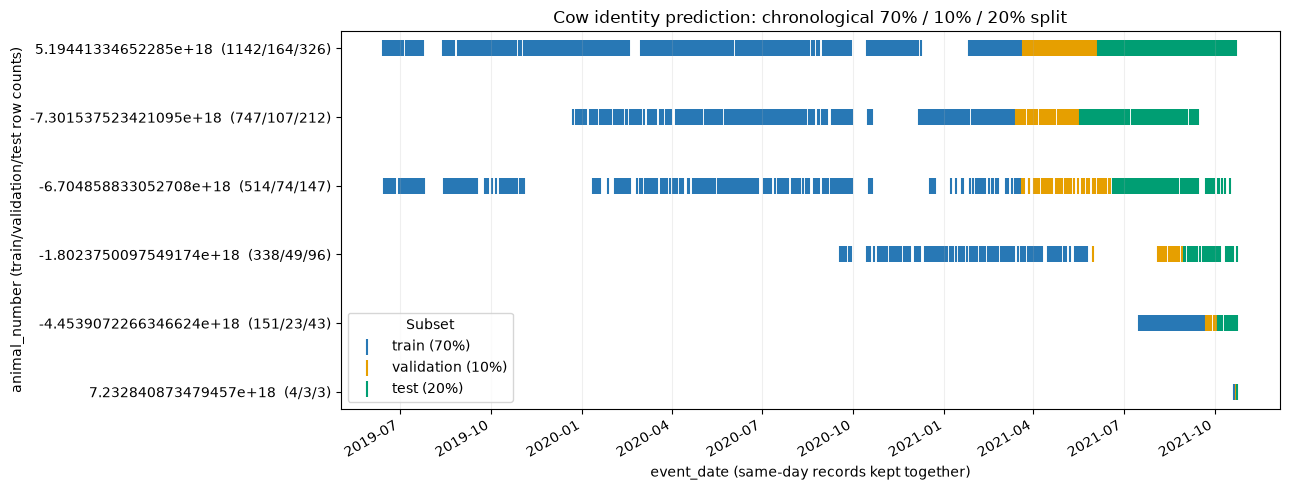

In [5]:
ordered_cows = per_cow_counts.sum(axis=1).sort_values().index
example_cows = ordered_cows[np.unique(np.linspace(0, len(ordered_cows)-1, min(6, len(ordered_cows)), dtype=int))]
colors = {'train': '#2878B5', 'validation': '#E69F00', 'test': '#009E73'}
fig, ax = plt.subplots(figsize=(13, 5))
for y, cow in enumerate(example_cows):
    for name, color in colors.items():
        dates = blocks.loc[blocks[COW].eq(cow) & blocks['_subset'].eq(name), TIME]
        ax.scatter(dates, np.full(len(dates), y), marker='|', s=130, color=color,
                   label=f'{name} ({SPLIT_PERCENT[name]}%)' if y == 0 else None)
ax.set_yticks(range(len(example_cows)), [
    f'{cow}  ({per_cow_counts.loc[cow, "train"]}/{per_cow_counts.loc[cow, "validation"]}/{per_cow_counts.loc[cow, "test"]})'
    for cow in example_cows])
ax.set_xlabel('event_date (same-day records kept together)')
ax.set_ylabel('animal_number (train/validation/test row counts)')
ax.set_title(f'Cow identity prediction: chronological {SPLIT_LABEL} split')
ax.legend(title='Subset', loc='best')
ax.grid(axis='x', alpha=.2)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## Identity labels and historical candidate records
The only target is `animal_number`. Predictor frames exclude the cow ID and split metadata. Keep validation/test IDs separately for scoring, and present those records to the future classifier as unidentified inputs.

The historical helper retrieves every candidate cow's training records before the query date. It never uses a held-out record's true identity to choose its history. Genuinely unidentified records remain in `unassigned_df` for later inference; they cannot supply supervised accuracy without verified labels.


In [6]:
NUMERIC = ['lactation_number', 'days_in_milk', 'average_milk_flow', '30_60_session',
           'yield_first_2_min_session_yield', 'session_yield', 'session_duration']
CATEGORICAL = ['reproduction_status', 'session_milking']
FEATURE_COLUMNS = NUMERIC + CATEGORICAL
assert not {COW, TIME, '_row_id', '_subset'}.intersection(FEATURE_COLUMNS)
X_train, X_validation, X_test = [frame[FEATURE_COLUMNS].copy()
                                for frame in [train_df, validation_df, test_df]]
y_train, y_validation, y_test = [frame[COW].copy()
                                for frame in [train_df, validation_df, test_df]]
assert all(labels.notna().all() for labels in [y_train, y_validation, y_test])
assert set(y_validation).issubset(set(y_train))
assert set(y_test).issubset(set(y_train))

def candidate_history_before(training, query_date):
    assert training['_subset'].eq('train').all()
    cutoff = pd.Timestamp(query_date)
    if pd.isna(cutoff):
        raise ValueError('A valid query date is required')
    return training.loc[training[TIME].lt(cutoff), [COW, TIME] + FEATURE_COLUMNS].copy()

print('Sole prediction target:', COW)
print('PASS: identity labels are excluded from all predictor frames.')


Sole prediction target: animal_number
PASS: identity labels are excluded from all predictor frames.


## Identity-only preprocessing from earlier training data
Fit imputers, scaling, and categorical encoding on labeled training rows strictly before the prediction cutoff. Missing feature imputation supports identity classification; no measurement is a prediction target. Apply the fitted transformer to validation/test inputs without their true IDs.

The future classifier must fit on the returned `X_fit` and `y_fit`. This example uses the earliest evaluation date as a fixed cutoff and reports cows absent from that historical snapshot. Later snapshots may use additional earlier training rows but must never predict earlier records. Tune on validation and reserve test labels for final scoring. The inherited full-dataset outlier filtering remains a limitation.


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NUMERIC = ['lactation_number', 'days_in_milk', 'average_milk_flow', '30_60_session',
           'yield_first_2_min_session_yield', 'session_yield', 'session_duration']
CATEGORICAL = ['reproduction_status', 'session_milking']

def predictor_frame(frame, numeric, categorical):
    result = frame[numeric + categorical].copy()
    result[numeric] = result[numeric].replace([np.inf, -np.inf], np.nan)
    for col in categorical:
        result[col] = result[col].map(lambda value: str(value) if pd.notna(value) else np.nan)
    return result

def fit_asof_preprocessor(training, *, prediction_cutoff):
    assert training['_subset'].eq('train').all()
    cutoff = pd.Timestamp(prediction_cutoff)
    fit_rows = training.loc[training[TIME].lt(cutoff) & training[COW].notna()]
    if fit_rows.empty:
        raise ValueError('No labeled training rows strictly before cutoff')
    numeric, categorical = NUMERIC.copy(), CATEGORICAL.copy()
    transformer = ColumnTransformer([
        ('numeric', Pipeline([('impute', SimpleImputer(strategy='median', keep_empty_features=True)),
                              ('scale', StandardScaler())]), numeric),
        ('categorical', Pipeline([('impute', SimpleImputer(strategy='most_frequent', keep_empty_features=True)),
                                  ('encode', OneHotEncoder(handle_unknown='ignore'))]), categorical)
    ])
    transformer.fit(predictor_frame(fit_rows, numeric, categorical))
    return {'transformer': transformer, 'numeric': numeric, 'categorical': categorical,
            'cutoff': cutoff, 'fit_rows': fit_rows,
            'X_fit': transformer.transform(predictor_frame(fit_rows, numeric, categorical)),
            'y_fit': fit_rows[COW].copy()}

def transform_asof(bundle, frame):
    if not frame[TIME].ge(bundle['cutoff']).all():
        raise ValueError('Prediction records precede the preprocessing cutoff; fit an earlier bundle')
    return bundle['transformer'].transform(
        predictor_frame(frame, bundle['numeric'], bundle['categorical']))

cutoff = min(validation_df[TIME].min(), test_df[TIME].min())
preprocessing_example = fit_asof_preprocessor(train_df, prediction_cutoff=cutoff)
validation_features_example = transform_asof(preprocessing_example, validation_df[[TIME] + FEATURE_COLUMNS].head(100))
test_features_example = transform_asof(preprocessing_example, test_df[[TIME] + FEATURE_COLUMNS].head(100))
assert preprocessing_example['fit_rows'][TIME].max() < cutoff
assert COW not in preprocessing_example['numeric'] + preprocessing_example['categorical']
for name, labels in [('validation', y_validation), ('test', y_test)]:
    cold_start = ~labels.isin(preprocessing_example['y_fit'])
    print(f'{name}: {int(cold_start.sum())} rows / {labels[cold_start].nunique()} cows without history at cutoff')
print('PASS: identity preprocessing uses only earlier training rows.')
print('Final split:', SPLIT_LABEL, '(training / validation / test)')


validation: 309572 rows / 5260 cows without history at cutoff
test: 619147 rows / 5260 cows without history at cutoff
PASS: identity preprocessing uses only earlier training rows.
Final split: 70% / 10% / 20% (training / validation / test)


## Evaluation scope
This notebook prepares an identity-only pipeline; it does not train the final classifier. Score predicted cow IDs against separately saved validation/test labels. Report cold-start coverage and accuracy without silently discarding cows that have no prior history. Missing-ID records have no ground truth for supervised scoring.

The experiment evaluates later records of familiar cows. The inherited full-dataset z-score filtering and floating-point ID representation remain limitations. No missing-measurement prediction model is included.
